# QCS sample notebook

This notebook demonstrates how to:
- load per-frame VMAF traces from text files
- compute survival curves
- compute QCS over a chosen operating interval
- compute several non-average pooling baselines


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from qcs import load_scores_txt, survival_curve, qcs, baselines

AV1  = Path('vmaf_scores/BerlinSeqs_av1_35000.txt')
HEVC = Path('vmaf_scores/BerlinSeqs_hevc_35000.txt')

q_av1  = load_scores_txt(AV1)
q_hevc = load_scores_txt(HEVC)

print('Loaded frames:', len(q_av1), '(AV1),', len(q_hevc), '(HEVC)')


Loaded frames: 3600 (AV1), 3600 (HEVC)


In [6]:
# Compute QCS and baseline poolers
a, b = 90.0, 100.0

results = {
  'AV1':  {**baselines(q_av1),  'QCS(90–100)%': qcs(q_av1,  a, b, scale='percent')},
  'HEVC': {**baselines(q_hevc), 'QCS(90–100)%': qcs(q_hevc, a, b, scale='percent')},
}

# Create a dataframe with the results
df = pd.DataFrame.from_dict(results, orient="index")
df.index.name = "codec"
df.round(4)

,mean,harmonic_mean,minkowski_p0.5,p10,worst_1pct_mean,QCS(90–100)%
codec,,,,,,
AV1,95.6763,95.6123,95.6605,92.2918,88.3254,57.1253
HEVC,94.9155,94.8345,94.8955,90.8790,86.5769,50.2353


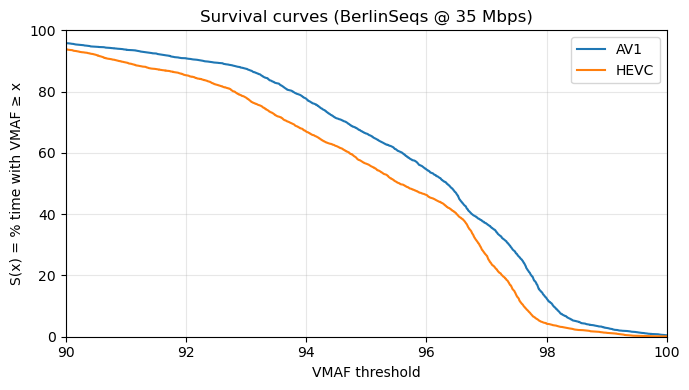

In [7]:
# Plot survival curves on percent scale
x_av1,  s_av1  = survival_curve(q_av1,  scale='percent')
x_hevc, s_hevc = survival_curve(q_hevc, scale='percent')

plt.figure(figsize=(7, 4))
plt.plot(x_av1,  s_av1,  label='AV1')
plt.plot(x_hevc, s_hevc, label='HEVC')
plt.xlim(a, b)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.xlabel('VMAF threshold')
plt.ylabel('S(x) = % time with VMAF ≥ x')
plt.title('Survival curves (BerlinSeqs @ 35 Mbps)')
plt.legend()
plt.tight_layout()
plt.show()


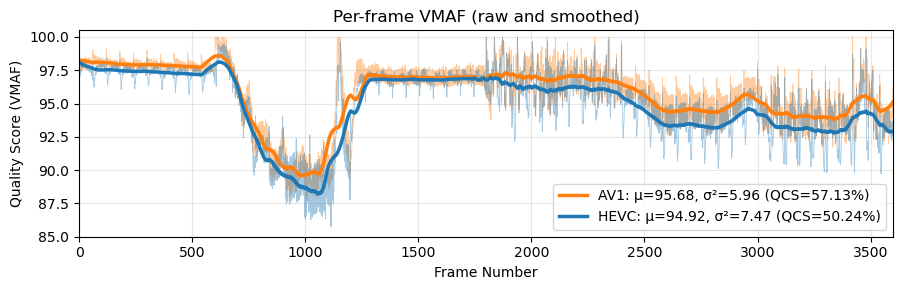

In [8]:
def smooth_moving_average(x, win=121):
    """
    Simple moving-average smoothing (for visualization only).
    Uses edge padding so output has same length as input.
    """
    x = np.asarray(x, dtype=float)
    if win < 3:
        return x.copy()
    if win % 2 == 0:
        win += 1
    pad = win // 2
    xp = np.pad(x, (pad, pad), mode="edge")
    kernel = np.ones(win, dtype=float) / win
    return np.convolve(xp, kernel, mode="valid")

def basic_stats(x):
    """Return mean, variance, std for a 1D array."""
    x = np.asarray(x, dtype=float)
    return float(np.mean(x)), float(np.var(x)), float(np.std(x))

# --- Time evolution plot (raw + smoothed) ---
fps = 60              # set to your true fps if known; used only for interpreting win
win = 121             # ~2 seconds at 60 fps
a, b = 90.0, 100.0    # QCS operating range
c_av1  = "tab:orange" # set color for the AV1 curve
c_hevc = "tab:blue"   # set color for the HEVC curve

av1_s  = smooth_moving_average(q_av1,  win=win)
hevc_s = smooth_moving_average(q_hevc, win=win)

mu_av1, var_av1, std_av1 = basic_stats(q_av1)
mu_hevc, var_hevc, std_hevc = basic_stats(q_hevc)

qcs_av1  = qcs(q_av1,  a, b, scale="percent")
qcs_hevc = qcs(q_hevc, a, b, scale="percent")

label_av1  = f"AV1: μ={mu_av1:.2f}, σ²={var_av1:.2f} (QCS={qcs_av1:.2f}%)"
label_hevc = f"HEVC: μ={mu_hevc:.2f}, σ²={var_hevc:.2f} (QCS={qcs_hevc:.2f}%)"

plt.figure(figsize=(9, 3))

# raw (faint) — same colors
plt.plot(q_av1,  linewidth=0.6, alpha=0.40, color=c_av1)
plt.plot(q_hevc, linewidth=0.6, alpha=0.40, color=c_hevc)

# smoothed (bold) — same colors
plt.plot(av1_s,  linewidth=2.5, alpha=1.0, color=c_av1,  label=label_av1)
plt.plot(hevc_s, linewidth=2.5, alpha=1.0, color=c_hevc, label=label_hevc)

plt.xlabel("Frame Number")
plt.ylabel("Quality Score (VMAF)")
plt.title("Per-frame VMAF (raw and smoothed)")
plt.grid(True, alpha=0.3)
plt.legend(loc="lower right")
plt.ylim(85, 100.5)
plt.xlim(0, len(q_av1))
plt.tight_layout()
plt.show()